<a href="https://colab.research.google.com/github/premkumar205/deeplearning-pjt/blob/rnn/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [ ]:
# load dataset
data=pd.read_csv('/content/optimized_waste_management_data.csv')


In [ ]:
data =data .fillna(method='ffill')

/tmp/ipykernel_187/3253247370.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data =data .fillna(method='ffill')


In [ ]:
waste_data=data[['waste_volume']]

In [ ]:
scaler_object = MinMaxScaler(feature_range=(0,1))
scalar=scaler_object.fit_transform(waste_data)

In [ ]:
def create_sequences(data, sequence_length):
  x=[]
  y=[]
  for i in range(len(data)-sequence_length):
    x.append(data[i:i+sequence_length])
    y.append(data[i+sequence_length])
  return np.array(x), np.array(y)


In [ ]:
sequence_length=10
x,y=create_sequences(scalar,sequence_length)
print(x.shape)
print(y.shape)

(1451, 10, 1)
(1451, 1)


In [ ]:
split = int(len(x)*0.8)
x_train=x[:split]
x_test=x[split:]
y_train=y[:split]
y_test=y[split:]

In [ ]:
model=Sequential()
model.add(SimpleRNN(50,activation='tanh',input_shape=(sequence_length,1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_7 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0372 - val_loss: 0.0140
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102 - val_loss: 0.0122
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0096 - val_loss: 0.0160
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0107 - val_loss: 0.0162
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0090 - val_loss: 0.0186
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0095 - val_loss: 0.0125
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0092 - val_loss: 0.0117
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102 - val_loss: 0.0121
Epoch 9/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - val_loss: 0.0122
Epoch 10/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0092 - val_loss: 0.0115


In [ ]:
loss = model.evaluate(x_test, y_test)
print('Test Loss:', loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0093
Test Loss: 0.010116050951182842


In [ ]:
model=Sequential()
model.add(SimpleRNN(50,activation='tanh',input_shape=(sequence_length,1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
predictions = model.predict(x_test)
predictions = scaler_object.inverse_transform(predictions)
y_test_actual = scaler_object.inverse_transform(y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


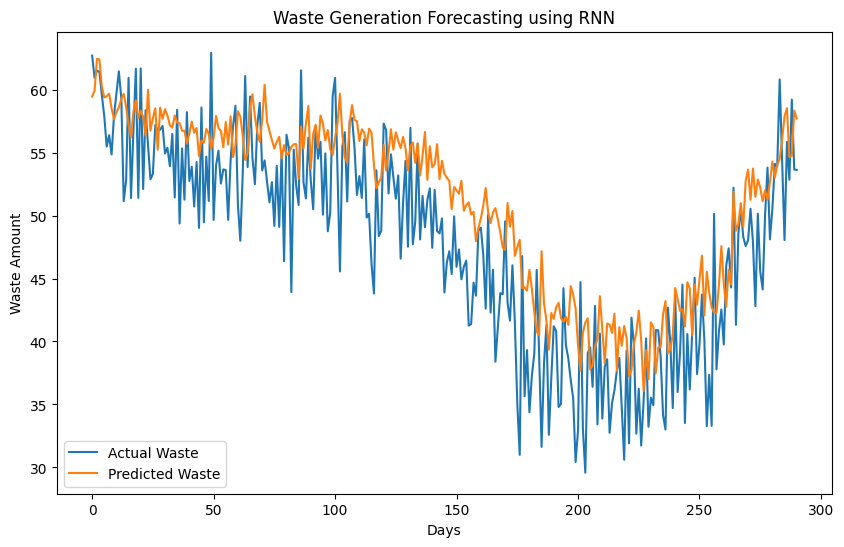

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(y_test_actual, label='Actual Waste')
plt.plot(predictions, label='Predicted Waste')

plt.title('Waste Generation Forecasting using RNN')
plt.xlabel('Days')
plt.ylabel('Waste Amount')
plt.legend()
plt.show()